# Laboratorio 2: Armado de un esquema de aprendizaje automático

En el laboratorio final se espera que puedan poner en práctica los conocimientos adquiridos en el curso, trabajando con un conjunto de datos de clasificación.

El objetivo es que se introduzcan en el desarrollo de un esquema para hacer tareas de aprendizaje automático: selección de un modelo, ajuste de hiperparámetros y evaluación.

El conjunto de datos a utilizar está en `./data/loan_data.csv`. Si abren el archivo verán que al principio (las líneas que empiezan con `#`) describen el conjunto de datos y sus atributos (incluyendo el atributo de etiqueta o clase).

Se espera que hagan uso de las herramientas vistas en el curso. Se espera que hagan uso especialmente de las herramientas brindadas por `scikit-learn`.

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from imblearn.over_sampling import SMOTE

import requests

## Carga de datos y división en entrenamiento y evaluación

La celda siguiente se encarga de la carga de datos (haciendo uso de pandas). Estos serán los que se trabajarán en el resto del laboratorio.

In [137]:

#dataset = pd.read_csv("./data/loan_data.csv", comment="#")
dataset = pd.read_csv("https://raw.githubusercontent.com/DiploDatos/IntroduccionAprendizajeAutomatico/master/data/loan_data.csv", comment="#")

# División entre instancias y etiquetas
X, y = dataset.iloc[:, 1:], dataset.TARGET
X_numeric = X.select_dtypes(include=['int64', 'float64'])
X_columns = X_numeric.columns.tolist()



# división entre entrenamiento y evaluación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)



Cargamos el dataset, separando los datos (X) de las etiquetas (y), además de realizar la división en entrenamiento y testeo con train_test_split.


Documentación:

- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

## Ejercicio 1: Descripción de los Datos y la Tarea

Responder las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponible para hacer la predicción?
4. ¿Qué atributos imagina ud. que son los más determinantes para la predicción?

**No hace falta escribir código para responder estas preguntas.**

In [138]:
url = "https://raw.githubusercontent.com/DiploDatos/IntroduccionAprendizajeAutomatico/master/data/loan_data.csv"
response = requests.get(url)

# Visualizamos el archivo, para responder de manera mas práctica
for line in response.text.splitlines():
    if line.startswith("#"):
        print(line)
    else:
        break

# Loan dataset based on the Kaggle Home Equity dataset
# Available at: https://www.kaggle.com/ajay1735/hmeq-data
#
# Context
# =======
# The consumer credit department of a bank wants to automate the decisionmaking
# process for approval of home equity lines of credit. To do this, they will
# follow the recommendations of the Equal Credit Opportunity Act to create an
# empirically derived and statistically sound credit scoring model. The model
# will be based on data collected from recent applicants granted credit through
# the current process of loan underwriting. The model will be built from
# predictive modeling tools, but the created model must be sufficiently
# interpretable to provide a reason for any adverse actions (rejections).
#
# Content
# =======
# The Home Equity dataset (HMEQ) contains baseline and loan performance
# information for 5,960 recent home equity loans. The target (BAD) is a binary
# variable indicating whether an applicant eventually defaulted or was
# serious

**RESPUESTAS**
1. Este es un conjunto de datos recopilados de solicitantes a los que se les ha
concedido crédito (préstamo).Contiene información relacionada con su situación financiera y antecedentes personales.
El objetivo es predecir si ese préstamo será riesgoso o no, para decidir si aprueban o rechazan una solicitud de crédito, y ayudar a prevenir morosidad y mejorar la rentabilidad de las carteras crediticias.

2. Consideramos que la variable objetivo es TARGET.

Esta variable indica si un cliente representa un riesgo crediticio o no:

* 1: cliente incumplió el prestamo (cliente con probabilidad de incumplimiento),
* 0: préstamo reembolsado (cliente con probabilidad de pago).

3. Atributos disponibles para la predicción:
* LOAN (Préstamo): Monto del préstamo solicitado.
* MORTDUE (Hipoteca): Monto adeudado de la hipoteca existente.
* VALUE (Valor): Valor de la propiedad.
* YOJ: Años en el trabajo actual.
* DEROG: Número de informes negativos.
* DELINQ: Número de líneas de crédito morosas.
* CLAGE: Edad de la linea de crédito mas vieja en meses.
* NINQ: Número de líneas de crédito recientes.
* CLNO: Número de líneas de crédito abiertas.
* DEBTINC: Ratio deuda-ingresos del solicitante.

4. Los atributos que consideramos mas determinantes para la predicción son:

  * DEBTINC (Ratio deuda-ingreso): Si alguien tiene muchas deudas en comparación a sus ingresos, representa un mayor riesgo.
  * DELINQ (Número de lineas de credito morosas): Un cliente que ya tuvo atrasos probablemente no sea confiable para un nuevo crédito.
  * DEROG (Registros negativos): Similar al anterior, pero vinculado a registros más serios.
  * CLAGE (Antigüedad del historial crediticio): Clientes con historial más largo suelen ser más confiables.
  * MORTDUE y VALUE: La relación entre deuda hipotecaria y valor de la propiedad puede ser un indicador de solidez patrimonial.
  * NINQ (Solicitudes recientes): Si posee muchas consultas de crédito en poco tiempo pueden reflejar una situación económica inestable.

## Analisis del dataset

Antes de iniciar con los ejercicios se analiza el dataset desde el punta de vista estadistico y descriptivo:

In [139]:
print("Descripción estadística del dataset:")
X.describe()

Descripción estadística del dataset:


,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000
mean,19111.758360,76316.051780,107321.088457,8.900216,0.187702,0.319849,180.300783,1.128910,21.857066,34.573408
std,11000.345961,46227.026585,56039.685066,7.552677,0.704882,0.928452,84.838308,1.664555,9.510840,9.308794
min,1700.000000,5627.000000,21144.000000,0.000000,0.000000,0.000000,0.486711,0.000000,0.000000,0.838118
25%,12000.000000,48984.750000,70787.250000,3.000000,0.000000,0.000000,116.970718,0.000000,16.000000,29.427210
50%,17000.000000,67201.000000,94198.000000,7.000000,0.000000,0.000000,174.967815,1.000000,21.000000,35.363407
75%,23900.000000,93731.500000,122976.250000,13.000000,0.000000,0.000000,232.261800,2.000000,27.000000,39.357987
max,89800.000000,399412.000000,512650.000000,41.000000,10.000000,10.000000,1168.233561,13.000000,65.000000,144.189001


In [140]:
print("\nInformación del dataset:")
X.info()


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1854 entries, 0 to 1853
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   LOAN     1854 non-null   int64  
 1   MORTDUE  1854 non-null   float64
 2   VALUE    1854 non-null   float64
 3   YOJ      1854 non-null   float64
 4   DEROG    1854 non-null   float64
 5   DELINQ   1854 non-null   float64
 6   CLAGE    1854 non-null   float64
 7   NINQ     1854 non-null   float64
 8   CLNO     1854 non-null   float64
 9   DEBTINC  1854 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 145.0 KB


Se grafica la distribucion de las variables del dataset

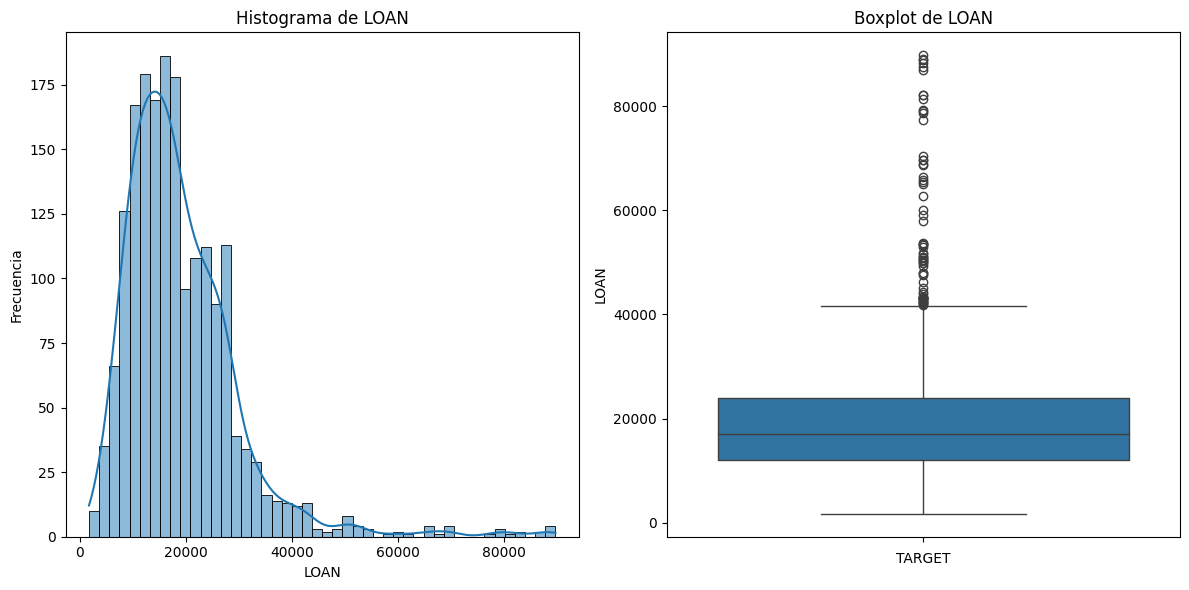

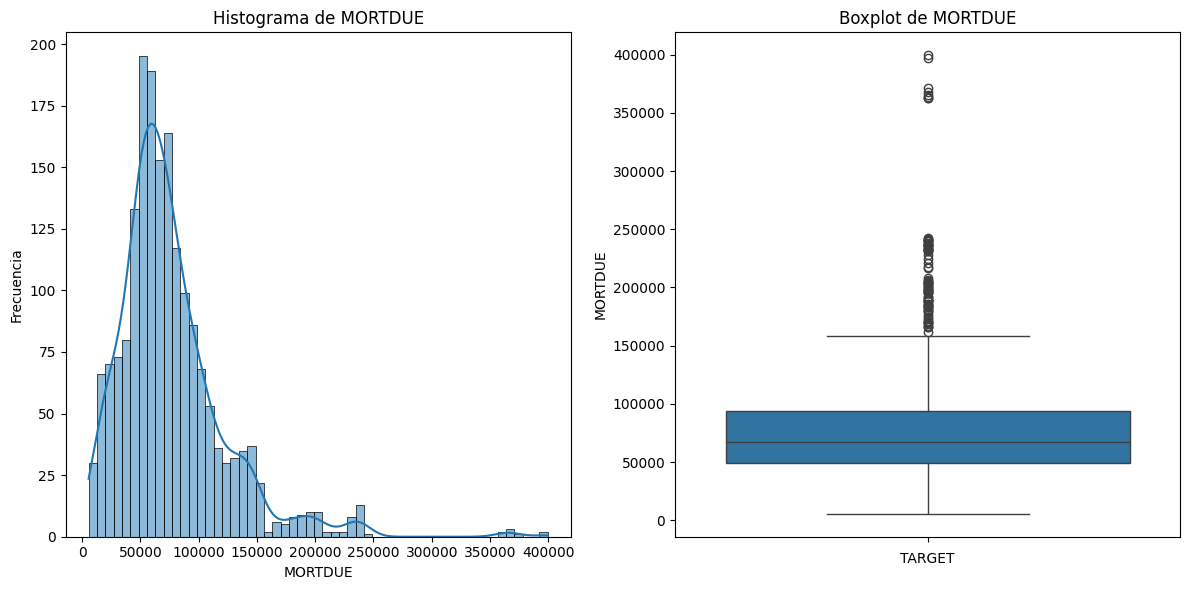

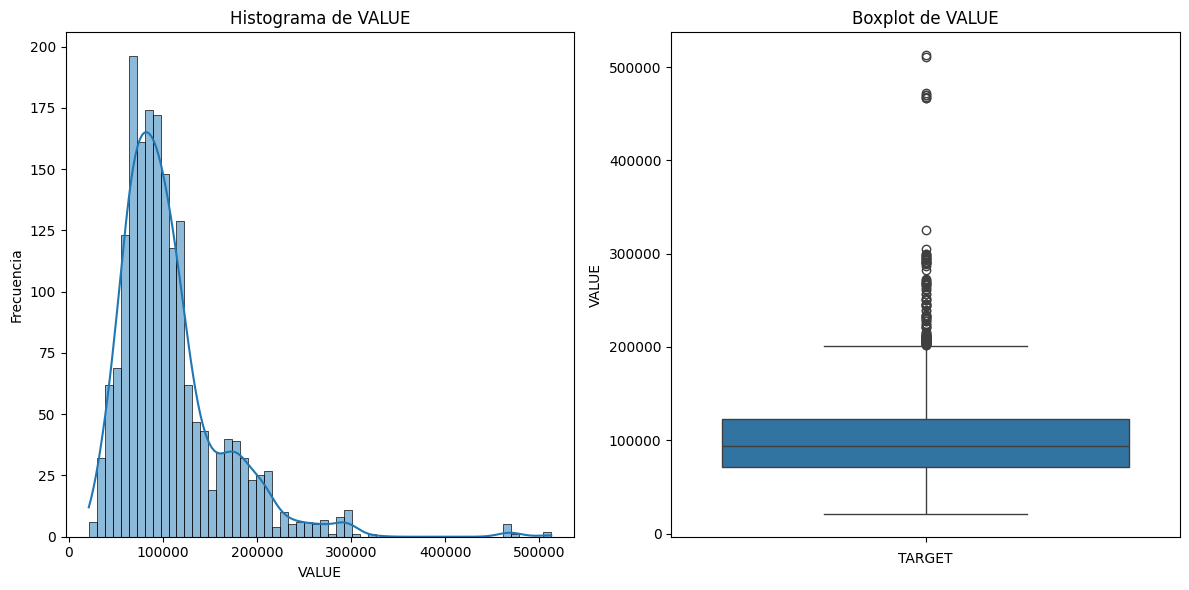

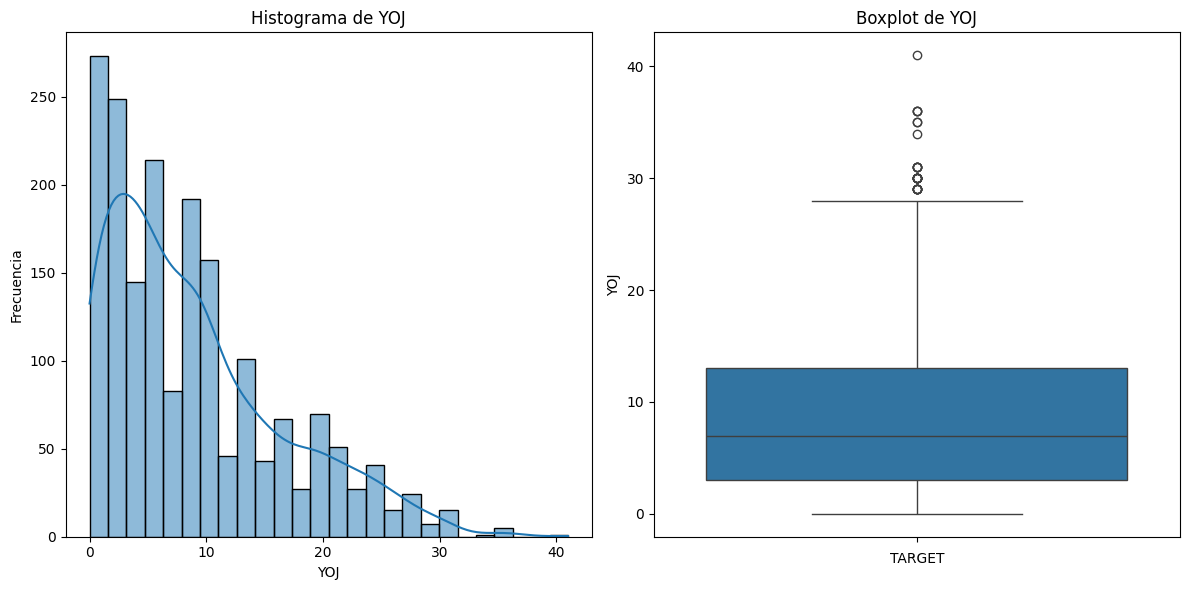

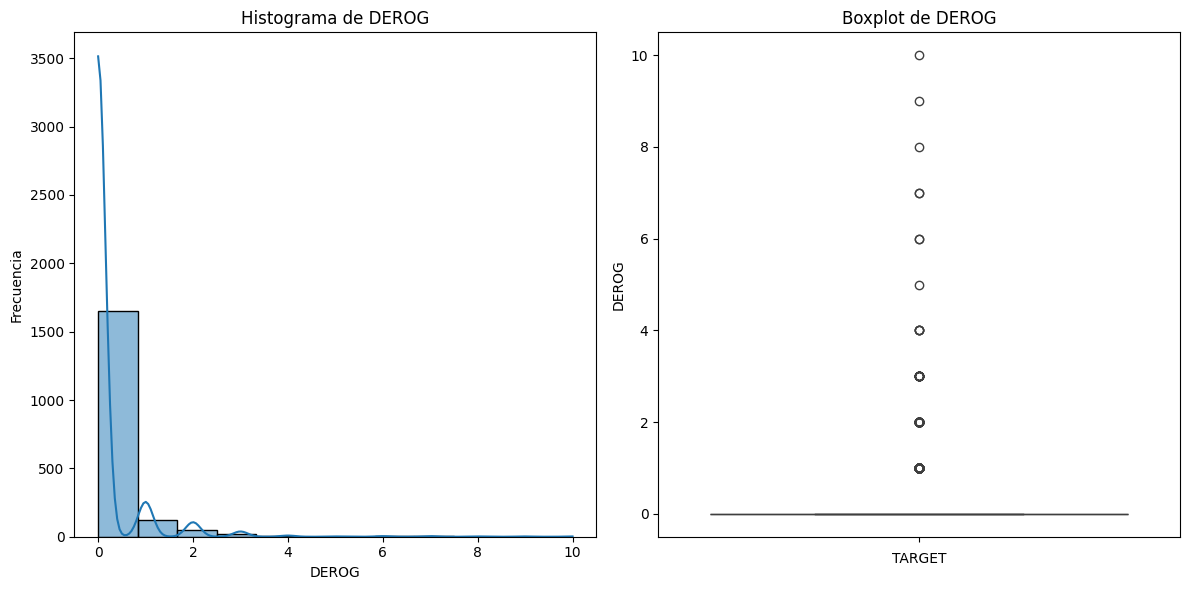

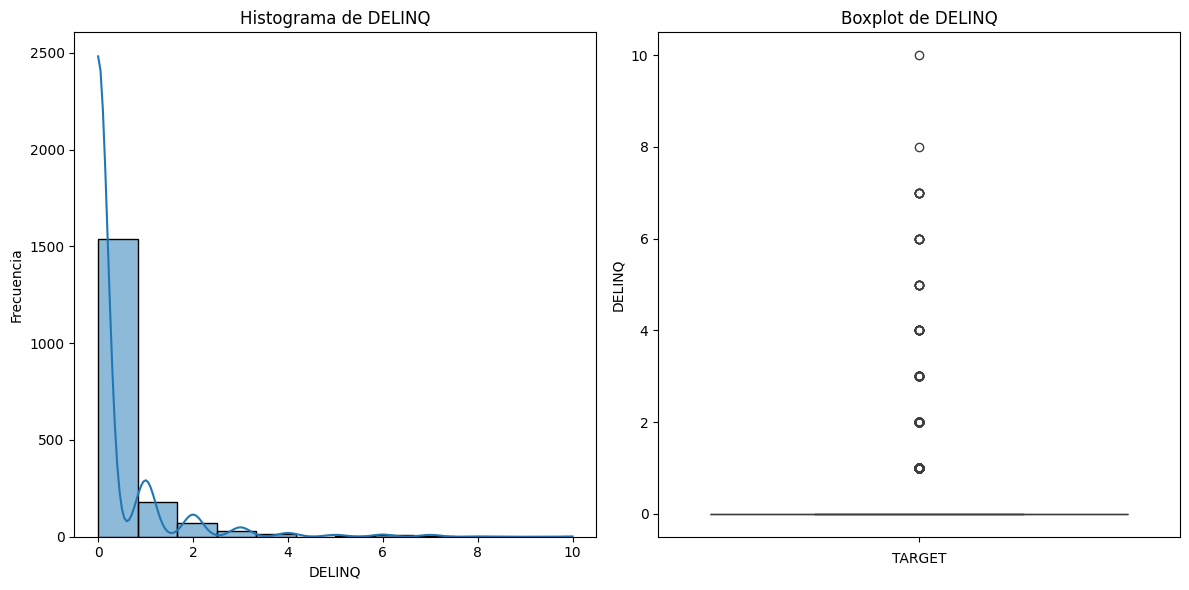

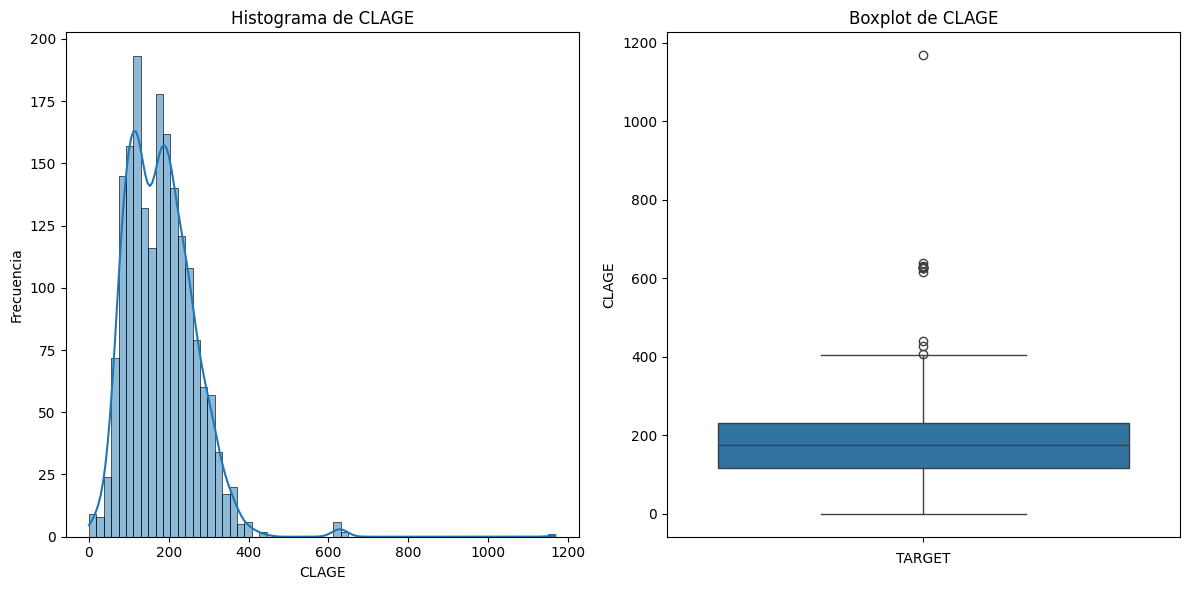

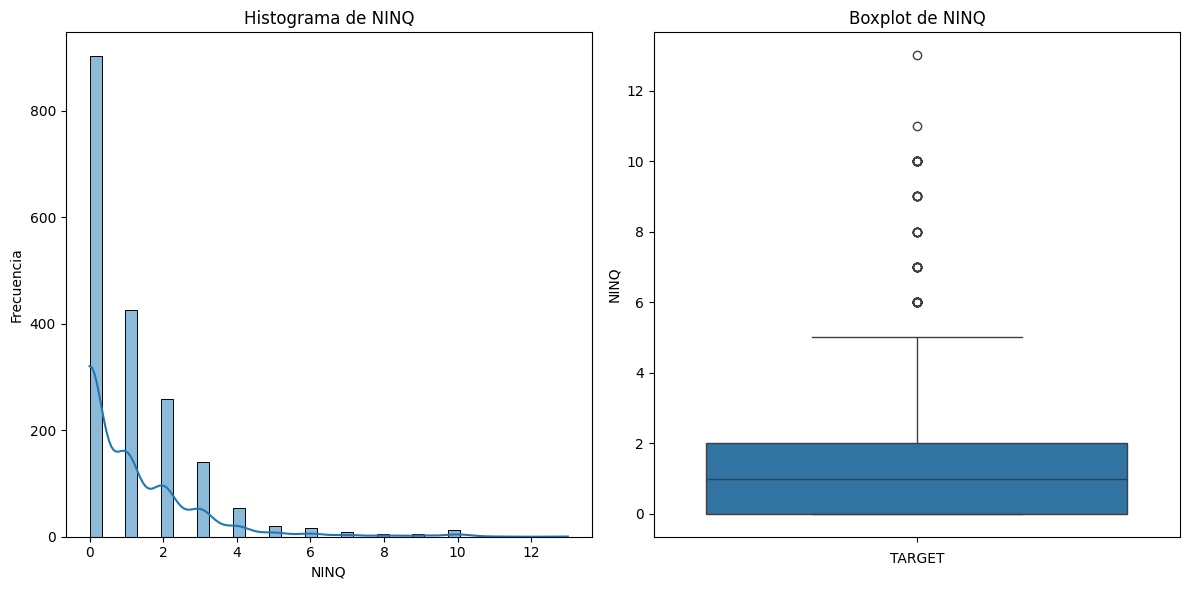

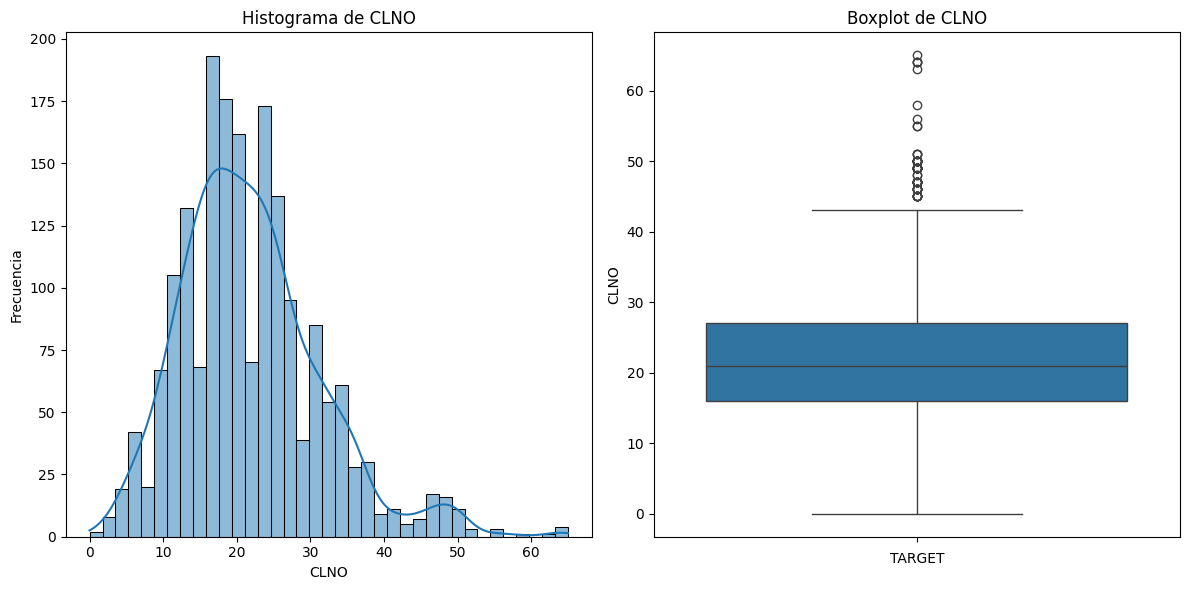

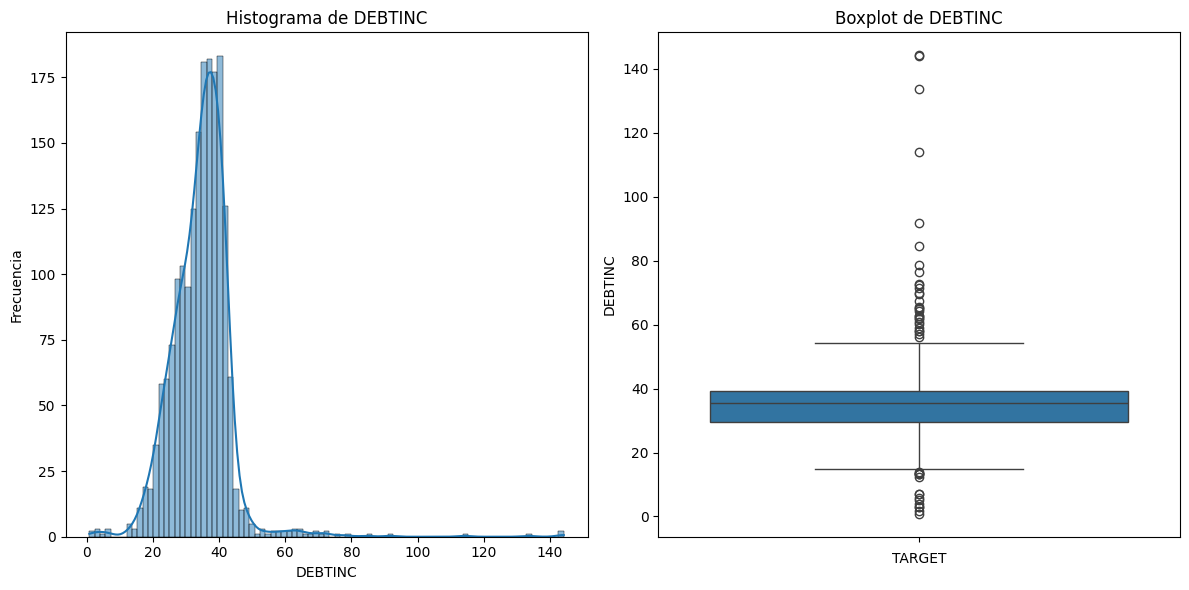

In [141]:
for column in X_numeric.columns:
    plt.figure(figsize=(12, 6))

    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(data=dataset, x=column, kde=True)
    plt.title(f'Histograma de {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')

    # Gráfico boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(data=dataset, y=column)
    plt.title(f'Boxplot de {column}')
    plt.xlabel('TARGET')
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

Comentarios:
* No se observan datos faltantes.
* El data set cuenta con 1854 registros y 10 variables.
* En los boxplot se puede observar que las variables presentan algunos valores extremos, habra que tenerlo en cuenta si esto afecta o no en el rendimiento del modelo.

Se grafica la distribucion de la variable target

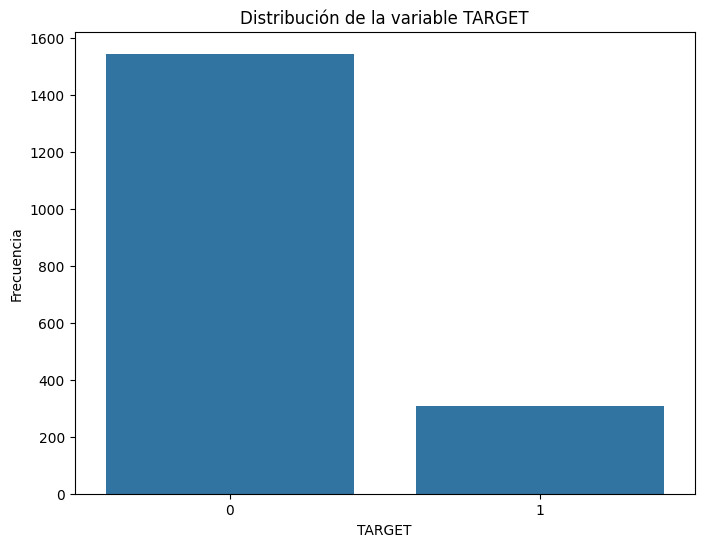

In [142]:
plt.figure(figsize=(8, 6))
sns.countplot(x=y)
plt.title('Distribución de la variable TARGET')
plt.xlabel('TARGET')
plt.ylabel('Frecuencia')
plt.show()

In [143]:
target_counts = y.value_counts()

total_count = target_counts.sum()
target_percentages = (target_counts / total_count) * 100

# Mostrar informacion
print("Cantidad de 0 (préstamos reembolsados) y 1 (préstamos incumplidos) en la variable TARGET:")
print(f"0: {target_counts.get(0, 0)} ({target_percentages.get(0, 0):.2f}%)")
print(f"1: {target_counts.get(1, 0)} ({target_percentages.get(1, 0):.2f}%)")

Cantidad de 0 (préstamos reembolsados) y 1 (préstamos incumplidos) en la variable TARGET:
0: 1545 (83.33%)
1: 309 (16.67%)


Vemos que el 83,3% de los registros correspondea a clientes con prestamos reembolsados (bajo riesgo), mientras que el 16,7% restante a los clientes con prestamos incumplidos (alto riesgo)


## Ejercicio 2: Predicción con Modelos Lineales

En este ejercicio se entrenarán modelos lineales de clasificación para predecir la variable objetivo.

Para ello, deberán utilizar la clase SGDClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/sgd.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html


### Ejercicio 2.1: SGDClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador SGDClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

In [144]:
# Entrenamos y evaluamos con el clasificador SGDClassifier, ademas escalamos.

clf = make_pipeline(
    StandardScaler(),
    SGDClassifier(random_state=0)
)

clf.fit(X_train, y_train)

# Predicciones
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

# Evaluamos métricas solicitadas
def evaluar_modelo(y_true, y_pred, conjunto):
    print(f"\n --Evaluación sobre el conjunto {conjunto}:")
    print(f"  Accuracy: {accuracy_score(y_true, y_pred):.3f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"  Recall: {recall_score(y_true, y_pred):.3f}")
    print(f"  F1 Score: {f1_score(y_true, y_pred):.3f}")
    print("Matriz de confusión:\n", confusion_matrix(y_true, y_pred))
    print("\nReporte de clasificación:")


# Visualizamos los Resultados
evaluar_modelo(y_train, y_train_pred, "de entrenamiento")
print(classification_report(y_train, y_train_pred))

evaluar_modelo(y_test, y_test_pred, "de evaluación")
print(classification_report(y_test, y_test_pred))


 --Evaluación sobre el conjunto de entrenamiento:
  Accuracy: 0.873
  Precision: 0.714
  Recall: 0.418
  F1 Score: 0.528
Matriz de confusión:
 [[1190   42]
 [ 146  105]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1232
           1       0.71      0.42      0.53       251

    accuracy                           0.87      1483
   macro avg       0.80      0.69      0.73      1483
weighted avg       0.86      0.87      0.86      1483


 --Evaluación sobre el conjunto de evaluación:
  Accuracy: 0.868
  Precision: 0.645
  Recall: 0.345
  F1 Score: 0.449
Matriz de confusión:
 [[302  11]
 [ 38  20]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       313
           1       0.65      0.34      0.45        58

    accuracy                           0.87       371
   macro avg       0.77      0.65      0.69       371
weighted avg

* **Matriz de confusion:**
      [ TP | FP ]
      [ FN | TN ]
* **Accuracy**: Representa el porcentaje de predicciones correctas sobre el total:

      (TP + TN) / (TP + TN + FP + FN)

* **Precisión**: Mide cuántas de las predicciones positivas fueron realmente correctas:

      TP / (TP + FP)

* **Recall**: Indica cuántos de los casos positivos reales fueron correctamente identificados:

      TP / (TP + FN)

* **F1-Score**: Es el promedio armónico entre precisión y recall:

      2 * (Precision * Recall) / (Precision + Recall)

Donde:

TP = Verdaderos Positivos

TN = Verdaderos Negativos

FP = Falsos Positivos

FN = Falsos Negativos





**Evaluación sobre el conjunto de entrenamiento**
* Accuracy (87.3%): el modelo acierta en casi 9 de cada 10 casos.
* Precision (71.4%): cuando el modelo dice "riesgoso", acierta 7 de cada 10 veces.
* Recall (41.8%): se detecta correctamente aproximadamente el 42% de los préstamos realmente riesgosos. Como el porcentaje es menor al 50% podemos considerar que es un valor bajo, lo que puede ser riesgoso para una entidad financiera.
* F1 Score (52.8%): Valor medio-bajo.

* Matriz de confusión:
  * 1190: bien clasificados como no riesgosos
  * 105: bien clasificados como riesgosos
  * 146: eran riesgosos pero el modelo no los detectó (falsos negativos)
  * 42: eran no riesgosos, pero fueron marcados como riesgosos (falsos positivos)

**Evaluación sobre el conjunto de evaluación**
* Accuracy (86.8%): valor alto, parecido al entrenamiento.
* Precision (64.5%): cuando predice "riesgoso", acierta 6.5 de cada 10 veces.
* Recall (34.5%): el modelo apenas detecta solo el 30% de los casos, porcentaje mas bajo que en el entrenamiento.
* F1 Score (44.9%): porcentaje bajo.

* Matriz de confusión:
  * 302: bien clasificados como no riesgosos
  * 20: bien clasificados como riesgosos
  * 11: eran riesgosos y no los detectó → falso negativo
  * 38: eran no riesgosos, pero los marcó como riesgosos → falso positivo
* Reporte de clasificación
  * Clase 0 (no riesgoso)
    * precision = 0.89: de todos los préstamos clasificados como "no riesgosos", el 89% realmente no lo eran.
    * recall = 0.96: el modelo encontró el 96% de los préstamos no riesgosos.
    * f1-score = 0.92: balance entre precisión y recall (alto porcentaje para esta clase).

  * Clase 1 (riesgoso)
    * precision = 0.65: de todos los préstamos que el modelo dijo que eran riesgosos, solo el 65% realmente lo eran.
    * recall = 0.34: solo identificó el 34% de los préstamos realmente riesgosos (bajo porcentaje para esta clase).
    * f1-score = 0.45: el rendimiento para esta clase es bajo (bajo como la clase anterior).


**Resumen**
Accuracy: Alto para ambas evaluaciones
Precision: Termino medio, podriamos decir aceptable
Recall: Bajo
F1 Score: No tan bajo, pero tal vez se ve penalizado por el recall



**Conclusiones**
  * Podemos inferir que el modelo funciona muy bien para detectar los préstamos no riesgosos (0), pero presenta porcentajes bajos para detectar los riesgosos (1).

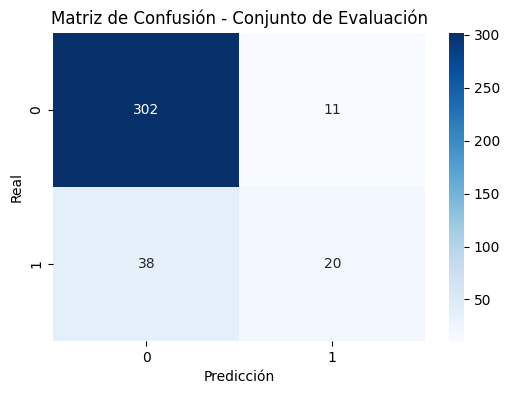

In [145]:
# Visualizamos con una Matriz de confusión en test
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Conjunto de Evaluación')
plt.show()

**Matriz de Confusión**
* 302: verdaderos negativos → casos bien clasificados como no riesgosos.
* 11: falsos negativos → eran riesgosos, pero el modelo los clasificó como no riesgosos (grave desde el punto de vista bancario).
* 38: falsos positivos → eran no riesgosos, pero el modelo los clasificó como riesgosos.
* 20: verdaderos positivos → casos bien clasificados como riesgosos.

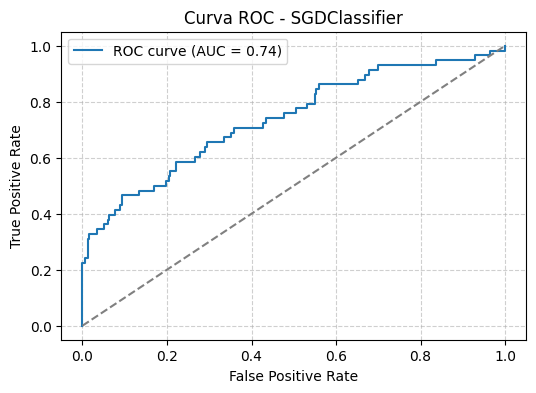

In [146]:
# Predecimos probabilidades de clase (decision_function porque SGDClassifier no tiene predict_proba por defecto)
y_scores = clf.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Línea base
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - SGDClassifier')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


Si bien esta metrica se suele utilizar mas para comparar modelos, el area bajo la curva ROC de 0,74 indica que el modelo tiene una capacidad moderada para distinguir entre clases.


### Ejercicio 2.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del SGDClassifier. Como mínimo, probar diferentes funciones de loss, tasas de entrenamiento y tasas de regularización.

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [147]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SGDClassifier(random_state=0))
])

param_grid = {
    'clf__loss': ['hinge', 'log_loss', 'modified_huber'],         # función de pérdida
    'clf__alpha': [0.0001, 0.001, 0.01],                          # regularización
    'clf__eta0': [0.01, 0.1, 1],                                  # tasa de aprendizaje inicial
    'clf__learning_rate': ['constant'],                           # fijamos estrategia para eta0
}

# validación cruzada
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring=['recall','f1'], refit='recall', return_train_score=True)
grid_search.fit(X_train, y_train)


# Visualizamos los resultados por combinación
results = pd.DataFrame(grid_search.cv_results_)
cols = ['param_clf__loss', 'param_clf__alpha', 'param_clf__eta0', 'mean_test_recall', 'std_test_recall']
print("\n Resultados de Grid Search (Recall promedio y desvío):")
print(results[cols].sort_values(by='mean_test_recall', ascending=False))


 Resultados de Grid Search (Recall promedio y desvío):
   param_clf__loss  param_clf__alpha  param_clf__eta0  mean_test_recall  \
23  modified_huber            0.0100             0.10          0.482510   
5   modified_huber            0.0001             0.10          0.482196   
7         log_loss            0.0001             1.00          0.478431   
14  modified_huber            0.0010             0.10          0.466196   
16        log_loss            0.0010             1.00          0.450353   
6            hinge            0.0001             1.00          0.407294   
15           hinge            0.0010             1.00          0.407137   
17  modified_huber            0.0010             1.00          0.401961   
8   modified_huber            0.0001             1.00          0.386667   
26  modified_huber            0.0100             1.00          0.378039   
2   modified_huber            0.0001             0.01          0.374667   
11  modified_huber            0.0010        

**Descripción de elección**

Como nuestro objetivo del modelo es:

* "Predecir si el préstamo será riesgoso o no, para decidir si aprueba o rechaza una solicitud de crédito, y ayudar a prevenir morosidad y mejorar la rentabilidad de las carteras crediticias"

Entonces se decide, minimzar la cantidad de falsos negativos

* Al maximizar el recall, nos aseguramos de minimizar los falsos negativos, de esta manera aseguramos evitar perdidas economicas al dar prestamos a personas insolventes.
Por otro lado, tenemos en cuenta tambien la metrica "f1", ya que este es un armónico entre el recall y precision, para de esta manera evitar perder clientes no riesgosos.

### Buscamos maximizar el recall

Reportamos tanto para el conjunto de entrenamiento como evaluación:

* Accuracy
* Precision
* Recall
* F1
* matriz de confusión

In [148]:

best_model = grid_search.best_estimator_
print(" Mejor configuración encontrada:", grid_search.best_params_)

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

evaluar_modelo(y_train, y_train_pred, "entrenamiento")
evaluar_modelo(y_test, y_test_pred, "evaluación")


 Mejor configuración encontrada: {'clf__alpha': 0.01, 'clf__eta0': 0.1, 'clf__learning_rate': 'constant', 'clf__loss': 'modified_huber'}

 --Evaluación sobre el conjunto entrenamiento:
  Accuracy: 0.825
  Precision: 0.473
  Recall: 0.275
  F1 Score: 0.348
Matriz de confusión:
 [[1155   77]
 [ 182   69]]

Reporte de clasificación:

 --Evaluación sobre el conjunto evaluación:
  Accuracy: 0.833
  Precision: 0.447
  Recall: 0.293
  F1 Score: 0.354
Matriz de confusión:
 [[292  21]
 [ 41  17]]

Reporte de clasificación:


Tenemos un recall muy bajo, seguimos trabajando para mejorarlo, para lo cual ajustaremos el umbral


In [149]:

decision_scores = best_model.decision_function(X_test)

# 2. Definimos un nuevo umbral más bajo (por defecto es 0.5)
umbral = 0.3
y_test_pred_umbral = (decision_scores > umbral).astype(int)

# 3. Evaluar
evaluar_modelo(y_test, y_test_pred_umbral, f"evaluación con umbral = {umbral}")



 --Evaluación sobre el conjunto evaluación con umbral = 0.3:
  Accuracy: 0.838
  Precision: 0.469
  Recall: 0.259
  F1 Score: 0.333
Matriz de confusión:
 [[296  17]
 [ 43  15]]

Reporte de clasificación:


Resultado: continuamos con un recall bajo, por lo que para mejorar esta situacion utilizaremos una tecnica llamada SMOTE.

SMOTE (del inglés Synthetic Minority Over-sampling Technique) es una técnica de aumento de datos usada para balancear clases desbalanceadas en problemas de clasificación.

A continuacion mostraremos el resultado de aplicar esta tecnica, ya que en nuestro caso tenemos un porcentaje muy bajo del target 1 (cliente riesgoso):



In [150]:

# Aplicamos SMOTE solo al entrenamiento, ya que no sirvio ajustar el umbral
smote = SMOTE(random_state=0)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Reentrenamos el modelo
model_smote = make_pipeline(StandardScaler(), SGDClassifier(loss='modified_huber', alpha=0.01,
                                                            eta0=0.1, learning_rate='constant',
                                                            random_state=0))
model_smote.fit(X_resampled, y_resampled)

y_test_pred_smote = model_smote.predict(X_test)
evaluar_modelo(y_test, y_test_pred_smote, "evaluación con SMOTE")


 --Evaluación sobre el conjunto evaluación con SMOTE:
  Accuracy: 0.790
  Precision: 0.384
  Recall: 0.569
  F1 Score: 0.458
Matriz de confusión:
 [[260  53]
 [ 25  33]]

Reporte de clasificación:


**Interpretación de resultados:**
* Accuracy (79%): El modelo acierta el 79% de los casos.
Al aumentar el recall es esperable que aumentan los falsos positivos
* Recall (56.9%): Observamos una gran mejora, antes este valor rondabamo 25-30%.
Esto significa que más de la mitad de los riesgosos ya no pasan desapercibidos
* Precision (38.4%): Este valor bajo (antes era ~45-47%), porque estás marcando más casos como riesgosos, incluyendo falsos positivos.
* F1 Score (45.8%): Es un balance entre precision y recall. Mejor que antes (donde tenías F1 cerca de 33%).

**Matriz de confusión**
* 33 riesgosos bien detectados (antes era 15–20)
* 25 riesgosos que aún no detecta
* 53 clientes no riesgosos fueron marcados como riesgosos (aumentaron los falsos positivos, pero es esperable)

## Visualizamos los resultados

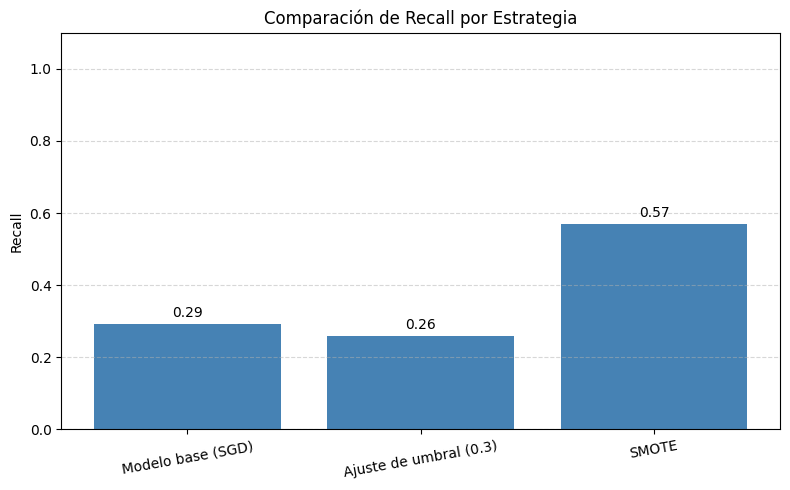

In [151]:
# Estrategias evaluadas (sin class_weight)
estrategias = [
    'Modelo base (SGD)',
    'Ajuste de umbral (0.3)',
    'SMOTE'
]

# Recalls correspondientes a cada estrategia
recalls = [
    0.293,  # Modelo base
    0.259,  # Ajuste de umbral
    0.569   # SMOTE
]

df_resultados = pd.DataFrame({
    'Estrategia': estrategias,
    'Recall': recalls
})


plt.figure(figsize=(8, 5))
bars = plt.bar(df_resultados['Estrategia'], df_resultados['Recall'], color='steelblue')
plt.title('Comparación de Recall por Estrategia')
plt.ylabel('Recall')
plt.ylim(0, 1.1)


for bar in bars:
    altura = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, altura + 0.02, f'{altura:.2f}', ha='center')

plt.xticks(rotation=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Conclusión**
Evaluamos diferentes modelos, y encontramos que el SMOTE, fue el que nos ayudó a maximizar el recall.


## Ejercicio 3: Árboles de Decisión

En este ejercicio se entrenarán árboles de decisión para predecir la variable objetivo.

Para ello, deberán utilizar la clase DecisionTreeClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/tree.html
  - https://scikit-learn.org/stable/modules/tree.html#tips-on-practical-use
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html

### Ejercicio 3.1: DecisionTreeClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador DecisionTreeClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión



 --Evaluación sobre el conjunto entrenamiento DecisionTreeClassifier:
  Accuracy: 1.000
  Precision: 1.000
  Recall: 1.000
  F1 Score: 1.000
Matriz de confusión:
 [[1232    0]
 [   0  251]]

Reporte de clasificación:

 --Evaluación sobre el conjunto evaluación DecisionTreeClassifier:
  Accuracy: 0.881
  Precision: 0.617
  Recall: 0.638
  F1 Score: 0.627
Matriz de confusión:
 [[290  23]
 [ 21  37]]

Reporte de clasificación:


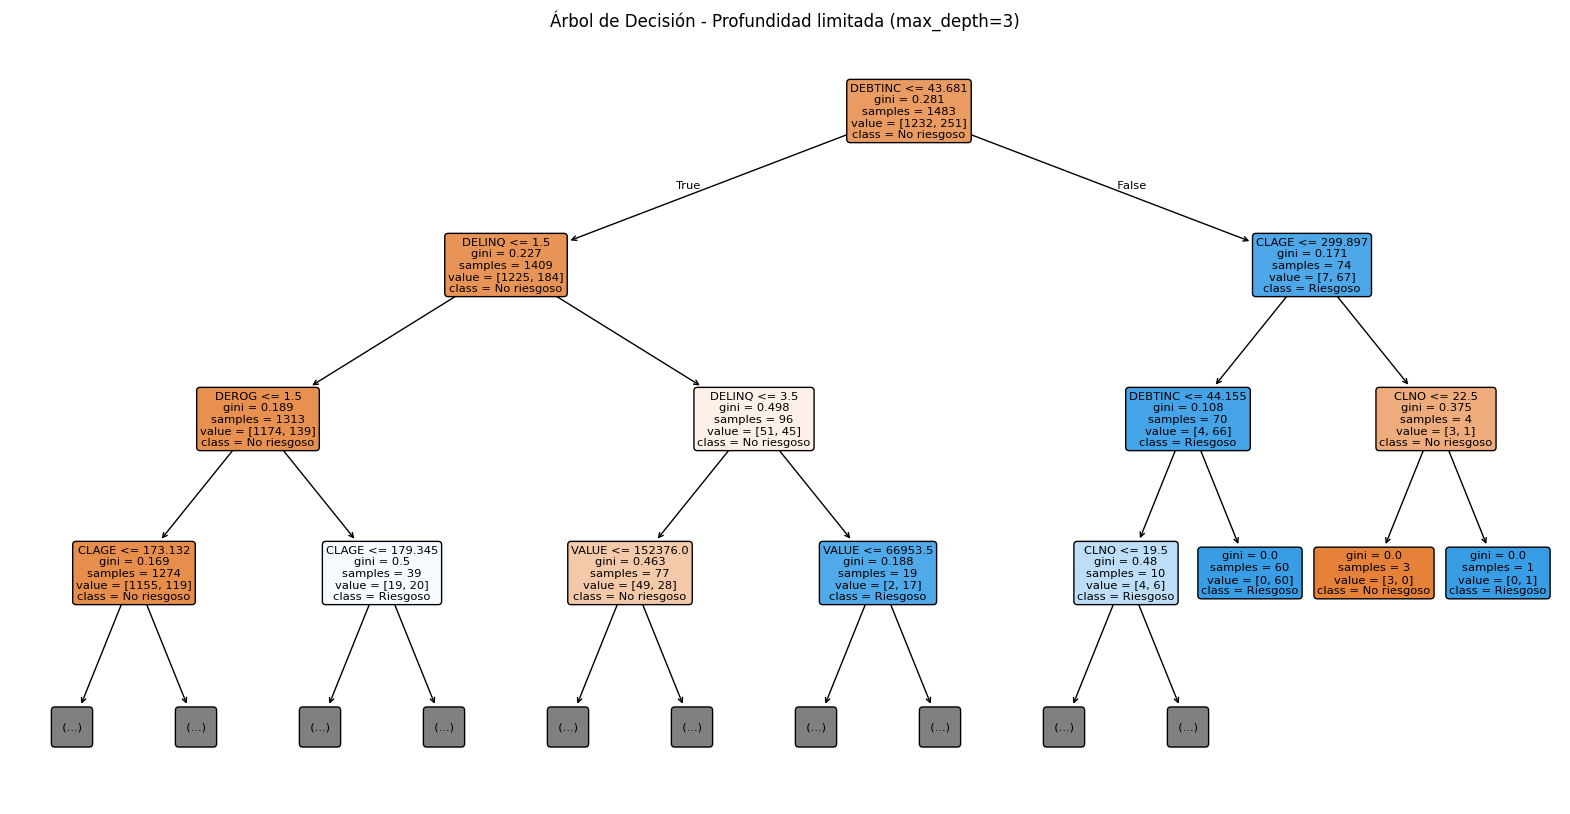

In [152]:

# Entrenamos el árbol de decisión con hiperparámetros por defecto
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

# Visualizamos la evaluación
evaluar_modelo(y_train, y_train_pred, "entrenamiento DecisionTreeClassifier")
evaluar_modelo(y_test, y_test_pred, "evaluación DecisionTreeClassifier")

# Visualizar árbol
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X_columns, class_names=["No riesgoso", "Riesgoso"], filled=True, rounded=True, max_depth=3)
plt.title("Árbol de Decisión - Profundidad limitada (max_depth=3)")
plt.show()


**Interpretación de resultados**
* Entrenamiento:
  * El árbol clasificó todos los ejemplos del conjunto de entrenamiento, por lo que podemos inferir que no hubo error: 0 falsos positivos y 0 falsos negativos.
    * Accuracy, Precision, Recall y F1 = 1, o sea 100%.
  * Entendemos que nos encontramos en un ejemplo de overfitting.

* Evaluación
  * Accuracy 88.1%: buen desempeño
  * Precision 61.7%: cuando el modelo predice "riesgoso", acierta 6 de cada 10 veces.
  * Recall 63.8%: detecta casi 2 de cada 3 préstamos riesgosos reales.
  * F1 Score 62.7%: balance decente entre precision y recall.

  * Matriz de confusión:
    * 290 → no riesgosos bien clasificados (verdaderos negativos)
    * 37 → riesgosos bien clasificados (verdaderos positivos)
    * 23 → no riesgosos mal clasificados (falsos positivos)
    * 21 → riesgosos no detectados (falsos negativos)

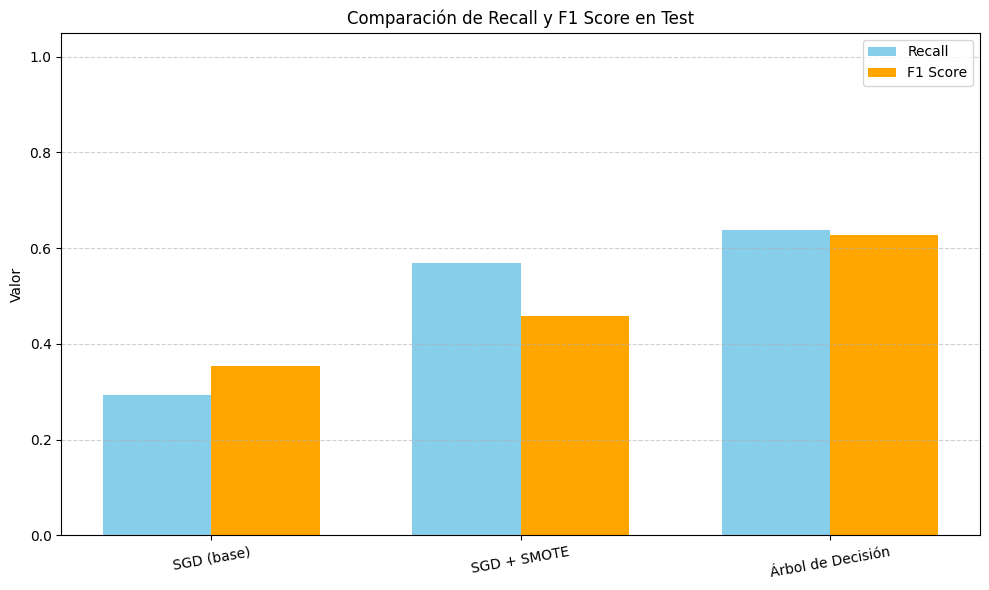

In [153]:
estrategias = [
    'SGD (base)',
    'SGD + SMOTE',
    'Árbol de Decisión'
]

# Métricas obtenidas en test
recalls = [
    0.293,   # SGD base
    0.569,   # SMOTE
    0.638    # Árbol
]

f1_scores = [
    0.354,   # SGD base
    0.458,   # SMOTE
    0.627    # Árbol
]

df_comparacion = pd.DataFrame({
    'Estrategia': estrategias,
    'Recall': recalls,
    'F1 Score': f1_scores
})

x = range(len(df_comparacion))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], df_comparacion['Recall'], width=width, label='Recall', color='skyblue')
plt.bar([i + width/2 for i in x], df_comparacion['F1 Score'], width=width, label='F1 Score', color='orange')

plt.xticks(ticks=x, labels=df_comparacion['Estrategia'], rotation=10)
plt.ylabel('Valor')
plt.ylim(0, 1.05)
plt.title('Comparación de Recall y F1 Score en Test')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



Se aprecia claramente que el modelo de clasificacion mediante Arbol de decision, tiene mejor rendimiento que los modelos de clasificacion del ejercicio 2.

Árbol de decisión: es el mejor modelo en ambas métricas, especialmente en F1 Score, mostrando un excelente equilibrio entre detección y precisión.

### Ejercicio 3.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del DecisionTreeClassifier. Como mínimo, probar diferentes criterios de partición (criterion), profundidad máxima del árbol (max_depth), y cantidad mínima de samples por hoja (min_samples_leaf).

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [154]:

tree = DecisionTreeClassifier(random_state=0)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 10]
}

grid_search = GridSearchCV(tree, param_grid, cv=5, scoring=['recall','f1'], refit='recall', return_train_score=True)
grid_search.fit(X_train, y_train)


results_df = pd.DataFrame(grid_search.cv_results_)
cols = ['param_criterion', 'param_max_depth', 'param_min_samples_leaf', 'mean_test_recall', 'std_test_recall']
print(" Accuracy promedio y desvío por combinación de hiperparámetros:")
print(results_df[cols].sort_values(by='mean_test_recall', ascending=False))


 Accuracy promedio y desvío por combinación de hiperparámetros:
   param_criterion param_max_depth  param_min_samples_leaf  mean_test_recall  \
21         entropy            None                       1          0.589569   
9             gini            None                       1          0.561490   
10            gini            None                       5          0.549490   
11            gini            None                      10          0.521647   
8             gini              10                      10          0.513647   
7             gini              10                       5          0.513569   
6             gini              10                       1          0.505725   
22         entropy            None                       5          0.501882   
18         entropy              10                       1          0.498118   
23         entropy            None                      10          0.477569   
20         entropy              10                      

In [155]:
# Mejor estimador
best_tree = grid_search.best_estimator_
print("\nMejor combinación encontrada:", grid_search.best_params_)

# Predicciones
y_train_pred = best_tree.predict(X_train)
y_test_pred = best_tree.predict(X_test)

# Evaluación
evaluar_modelo(y_train, y_train_pred, "entrenamiento")
evaluar_modelo(y_test, y_test_pred, "evaluación")



Mejor combinación encontrada: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1}

 --Evaluación sobre el conjunto entrenamiento:
  Accuracy: 1.000
  Precision: 1.000
  Recall: 1.000
  F1 Score: 1.000
Matriz de confusión:
 [[1232    0]
 [   0  251]]

Reporte de clasificación:

 --Evaluación sobre el conjunto evaluación:
  Accuracy: 0.892
  Precision: 0.655
  Recall: 0.655
  F1 Score: 0.655
Matriz de confusión:
 [[293  20]
 [ 20  38]]

Reporte de clasificación:


**Interpretación Resultados**

Entrenamiento:
  * El árbol clasificó todos los ejemplos del conjunto de entrenamiento, por lo que podemos inferir que no hubo error: 0 falsos positivos y 0 falsos negativos.
    * Accuracy, Precision, Recall y F1 = 1, o sea 100%.
  * Entendemos que nos encontramos en un ejemplo de overfitting.

Evaluación:
* Accuracy: 89.2% visualizamos que sigue siendo alto y generaliza bien.
* Precision: 65% acierta 3 de cada 4.
* Recall: 65.5% detecta la mitad de los riesgosos reales.
* F1 Score: 65.5% buen balance, pero bajó un poco comparado al árbol sin limitar.

Conclusión:
El árbol ajustado generaliza mejor (menos overfitting), pierde algo de recall, pero gana precisión y accuracy


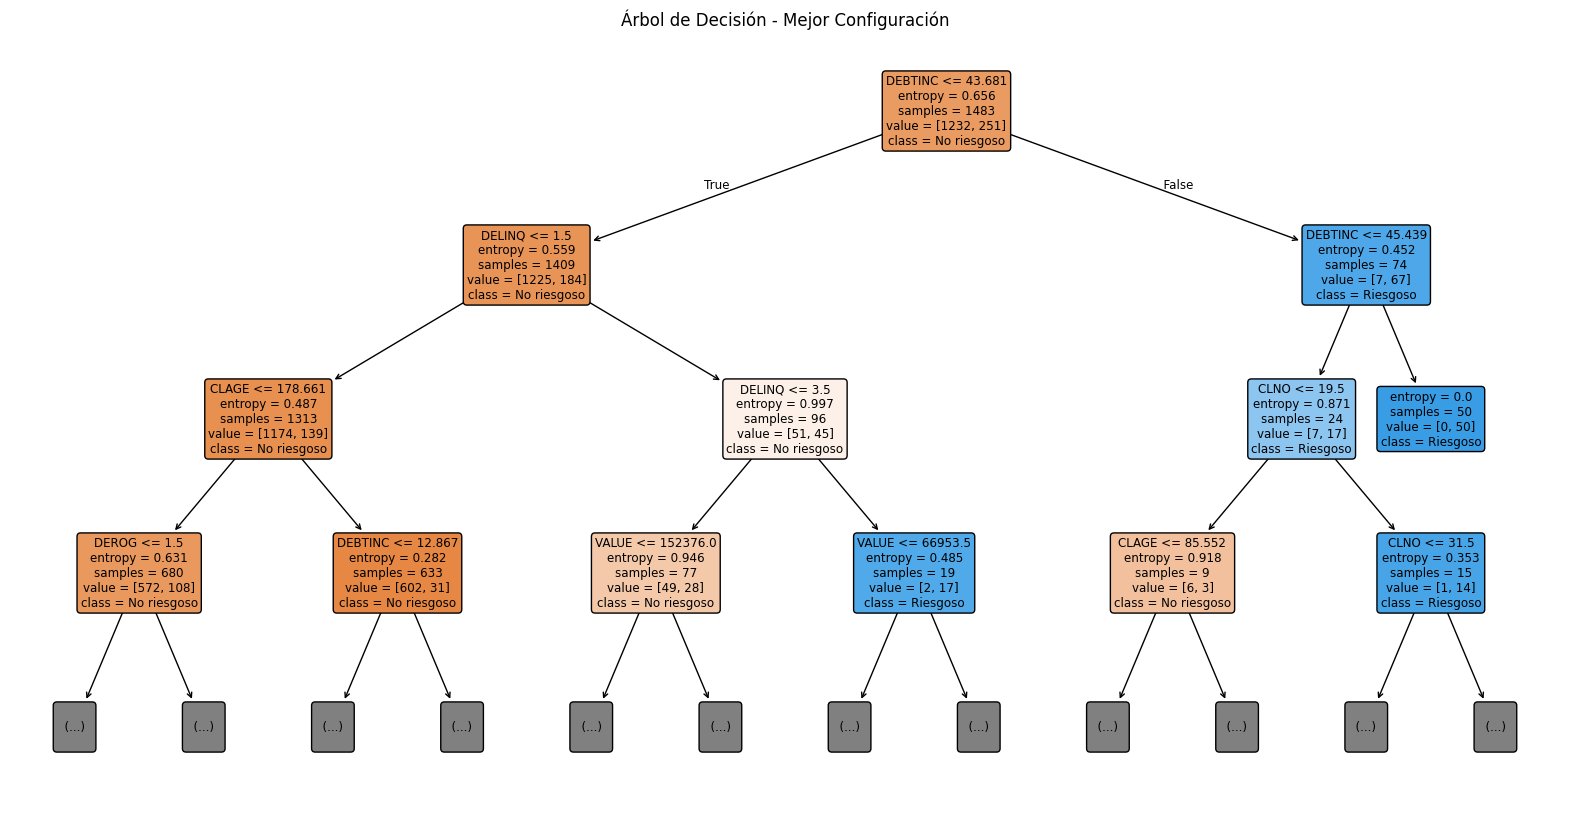

In [156]:

feature_names = X_numeric.columns.tolist()

# Visualizamos el árbol
plt.figure(figsize=(20, 10))
plot_tree(best_tree,
          feature_names=feature_names,
          class_names=["No riesgoso", "Riesgoso"],
          filled=True,
          rounded=True, max_depth=3)
plt.title("Árbol de Decisión - Mejor Configuración")
plt.show()


Al igual que en el ejercicio 2, se utiliza la tecnica SMOTE para mejorar el rendimiento del modelo:


 --Evaluación sobre el conjunto entrenamiento con SMOTE:
  Accuracy: 1.000
  Precision: 1.000
  Recall: 1.000
  F1 Score: 1.000
Matriz de confusión:
 [[1232    0]
 [   0  251]]

Reporte de clasificación:

 --Evaluación sobre el conjunto evaluación con SMOTE:
  Accuracy: 0.884
  Precision: 0.627
  Recall: 0.638
  F1 Score: 0.632
Matriz de confusión:
 [[291  22]
 [ 21  37]]

Reporte de clasificación:


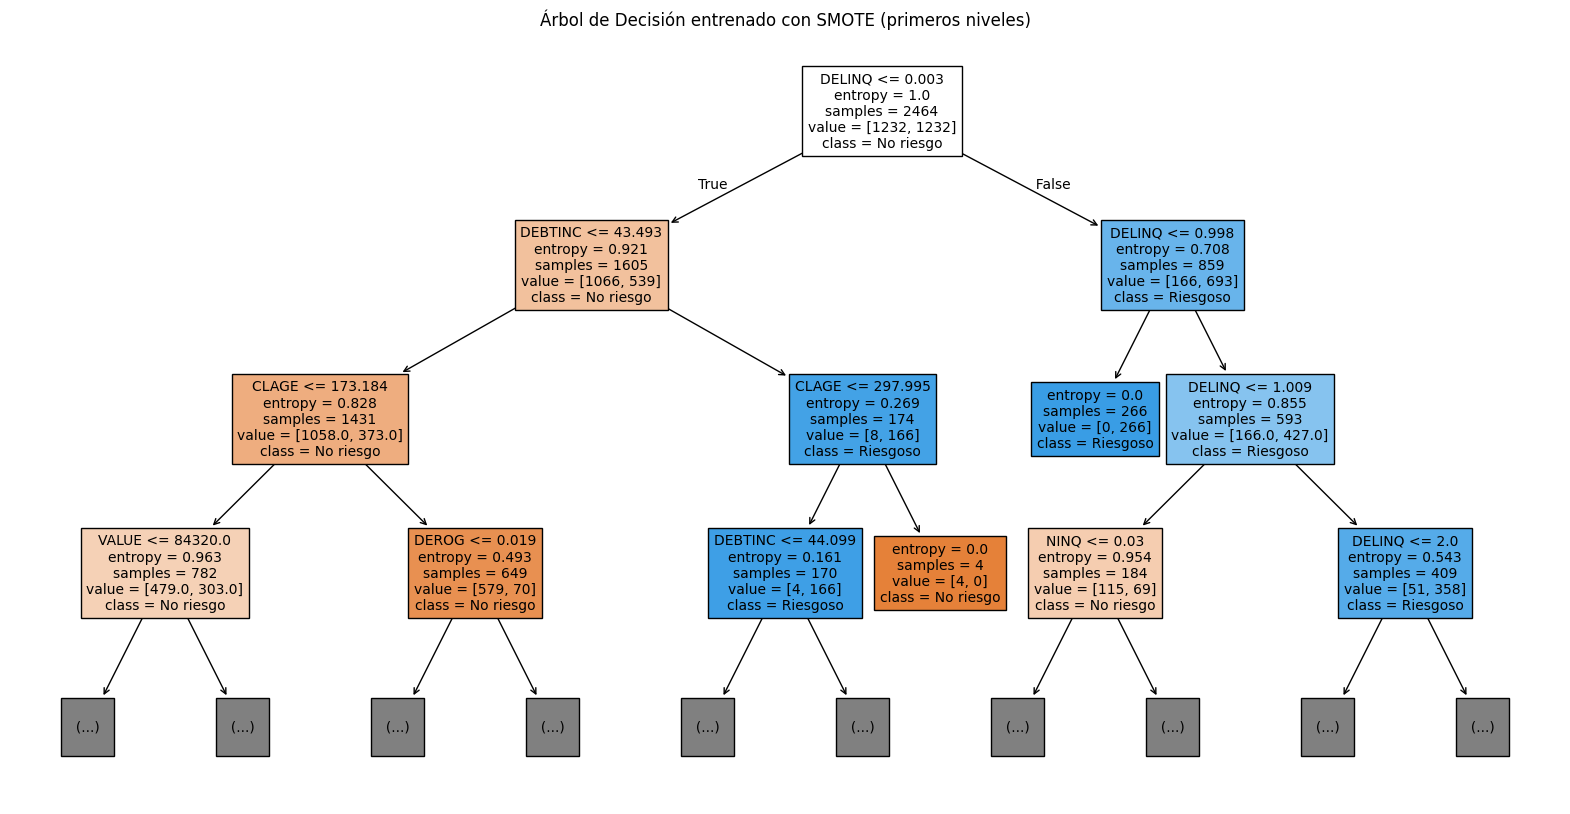

In [157]:
# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Entrenar árbol
tree_model = DecisionTreeClassifier(criterion='entropy', max_depth=None, min_samples_leaf=1, random_state=0) # Se utiliza el bestmodel: Mejor combinación encontrada: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1}
tree_model.fit(X_train_smote, y_train_smote)



# Evaluación
y_train_pred = tree_model.predict(X_train)
y_test_pred = tree_model.predict(X_test)

evaluar_modelo(y_train, y_train_pred, "entrenamiento con SMOTE")
evaluar_modelo(y_test, y_test_pred, "evaluación con SMOTE")

# Visualizar árbol
plt.figure(figsize=(20, 10))
plot_tree(tree_model, filled=True, max_depth=3, fontsize=10, feature_names=X.columns, class_names=["No riesgo", "Riesgoso"])
plt.title("Árbol de Decisión entrenado con SMOTE (primeros niveles)")
plt.show()

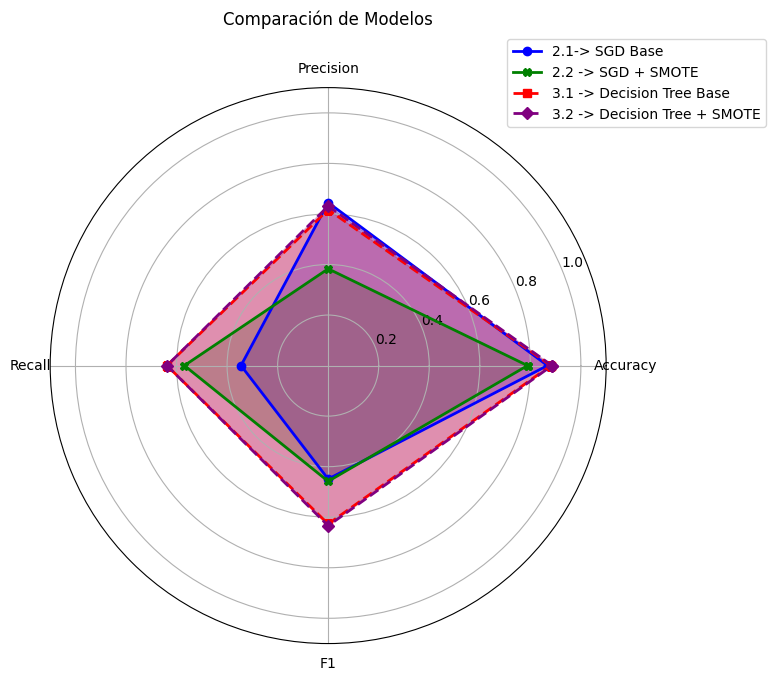

In [158]:
# Datos de los modelos para el gráfico de rombo
models = ['2.1-> SGD Base', '2.2 -> SGD + SMOTE', '3.1 -> Decision Tree Base', '3.2 -> Decision Tree + SMOTE']

# Métricas de evaluación (Accuracy, Precision, Recall, F1) .
metrics_data = {
    '2.1-> SGD Base': [0.868, 0.645, 0.345, 0.449],
    '2.2 -> SGD + SMOTE': [0.789, 0.383, 0.569, 0.458],
    '3.1 -> Decision Tree Base': [0.881, 0.617, 0.638, 0.627],
    '3.2 -> Decision Tree + SMOTE': [0.886, 0.631, 0.638, 0.634]
}


# Nombres de las métricas
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']

# Crear el gráfico de rombo (radar chart)
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Ángulos para cada métrica
angles = np.linspace(0, 2*np.pi, len(metrics_names), endpoint=False).tolist()
angles += angles[:1] # Cierra el círculo

# Función para agregar un modelo al gráfico
def add_model_to_radar(model_name, metrics, color, linestyle='-', marker='o'):
    values = metrics + metrics[:1] # Cierra el círculo
    ax.plot(angles, values, color=color, linewidth=2, linestyle=linestyle, marker=marker, label=model_name)
    ax.fill(angles, values, color=color, alpha=0.25)

# Agregar cada modelo al gráfico
colors = ['blue', 'green', 'red', 'purple']
linestyles = ['-', '-', '--', '--'] # Diferenciar los modelos base de los que usan SMOTE
markers = ['o', 'X', 's', 'D']

for i, model_name in enumerate(models):
    add_model_to_radar(model_name, metrics_data[model_name], colors[i], linestyles[i], markers[i])

# Configurar el gráfico
ax.set_thetagrids(np.degrees(angles[:-1]), metrics_names)
ax.set_title("Comparación de Modelos", y=1.1)
ax.grid(True)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Establecer los límites del eje radial
ax.set_ylim(0, 1.1) # Establece un límite máximo ligeramente mayor que 1 para que los puntos más altos se vean bien

plt.tight_layout()
plt.show()



**Conclusiones:**

* La visualización comparativa de métricas en el conjunto de evaluación destacó que los modelos de Árbol de Decisión (tanto el base como el ajustado con y sin SMOTE) superaron al `SGDClassifier` en las métricas clave para la detección de casos de riesgo (*Recall* y *F1 Score*). Aunque el `SGDClassifier` con SMOTE logró un *recall* mejor que el `SGDClassifier` base, el Árbol de Decisión obtuvo un *recall* aún mayor y un mejor *F1 Score*, indicando un mejor balance general.


* Considerando el objetivo de identificar préstamos riesgosos para mitigar pérdidas y buscando un balance razonable, el `DecisionTreeClassifier` ajustado (o incluso el base)** parece ser el modelo más adecuado en este análisis preliminar. Si bien el árbol con SMOTE tiene métricas similares, el árbol sin SMOTE ofrece un rendimiento comparable en *recall* y *F1* sin la complejidad adicional de SMOTE y manteniendo un mejor *accuracy* general.

